# **Dados:**

 **Aluno(a):** `Levi de Lima Pereira Júnior`

 **Matrícula:** ``

## Objetivo do Laboratório

Neste laboratório, você irá **analisar a lei de Zipf e a construção de modelos de linguagem N-grams** em um texto. O objetivo é verificar se a lei se mantém em diversas etapas do pré-processamento. Além disso, você irá gerar seu próprio modelo de linguagem n-grama.

### Bibliotecas que você pode utilizar:

- [NLTK (Natural Language Toolkit)](https://www.nltk.org/): Uma das bibliotecas mais tradicionais, com ferramentas para tokenização, stemming, stopwords, N-grams, entre outras.
- [spaCy](https://spacy.io/): Biblioteca moderna e eficiente para tarefas de PLN, como lematização, dependência sintática e análise gramatical.
- [Scikit-learn](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction): Possui recursos para extração de características a partir de texto (como vetorização e contagem de N-grams).

**Dica:** Comece com o **NLTK**, pois ela tem suporte direto e simples para geração de **N-grams**.


## **Bibliotecas**

In [3]:
import requests
from bs4 import BeautifulSoup
import nltk
import re

# Import StopWords
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import PorterStemmer

# Importação de Modelos Bi-Grams e Tri-Grams
from nltk import bigrams, trigrams

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Obtenção dos Dados**

Para a atividade desse laborátorio, iremos utilizar dados textuais oriundos do **[Project Gutenberg](https://www.gutenberg.org/)**. O texto escolhido é a obra Dom Casmurro.

In [6]:
#Endereço do texto e seu download
url_download = "https://www.gutenberg.org/cache/epub/55752/pg55752-images.html"
r = requests.get(url_download)
r.encoding = 'utf-8'
html = r.text
print(html[0:2000])

<!DOCTYPE html>
<html lang="pt">
<head>
<meta charset="utf-8"><style>
#pg-header div, #pg-footer div {
    all: initial;
    display: block;
    margin-top: 1em;
    margin-bottom: 1em;
    margin-left: 2em;
}
#pg-footer div.agate {
    font-size: 90%;
    margin-top: 0;
    margin-bottom: 0;
    text-align: center;
}
#pg-footer li {
    all: initial;
    display: block;
    margin-top: 1em;
    margin-bottom: 1em;
    text-indent: -0.6em;
}
#pg-footer div.secthead {
    font-size: 110%;
    font-weight: bold;
}
#pg-footer #project-gutenberg-license {
    font-size: 110%;
    margin-top: 0;
    margin-bottom: 0;
    text-align: center;
}
#pg-header-heading {
    all: inherit;
    text-align: center;
    font-size: 120%;
    font-weight: bold;
}
#pg-footer-heading {
    all: inherit;
    text-align: center;
    font-size: 120%;
    font-weight: normal;
    margin-top: 0;
    margin-bottom: 0;
}
#pg-header #pg-machine-header p {
    text-indent: -4em;
    margin-left: 4em;
    margin-top

In [7]:
# Exibir o livro
soup = BeautifulSoup(html, 'html.parser')
texto = soup.get_text()
print(texto[32000:34000])

ia a descer á chacara, e
passar ao quintal visinho. Comecei a andar de um
lado para outro, estacando para amparar-me, e
andava outra vez e estacava. Vozes confusas repetiam
o discurso do José Dias:
«Sempre juntos...»
«Em segredinhos...»
«Se elles pegam de namoro...»
Tijolos que pisei e repisei naquella tarde, columnas
amarelladas que me passastes á direita ou á
esquerda, segundo eu ia ou vinha, em vós me ficou
a melhor parte da crise, a sensação de um goso novo,
que me envolvia em mim mesmo, e logo me dispersava,
e me trazia arrepios, e me derramava não
sei que balsamo interior. Ás vezes dava por mim,
sorrindo, um ar do riso de satisfação, que desmentia
a abominação do meu peccado. E as vozes repetiam-se
confusas:
«Em segredinhos...»
«Sempre juntos...»
«Se elles pegam de namoro...»
Um coqueiro, vendo-me inquieto e adivinhando
a causa, murmurou de cima de si que não era feio
que os meninos de quinze annos andassem nos
cantos com as meninas de quatorze; ao contrario,
os adolescentes daqu

In [9]:
#Remove informações do início e fim do capítulo. Elas não são importantes, deixando apenas o texto em português.
def limpar_texto_gutenberg(texto):
    inicio_frase = "Do titulo."
    inicio = texto.find(inicio_frase)
    fim = texto.find("*** END OF THE PROJECT")
    if inicio != -1 and fim != -1:
        return texto[inicio + len(inicio_frase):fim]
    return texto

texto_original = limpar_texto_gutenberg(texto)
print(texto_original[:700])


Uma noite destas, vindo da cidade para o
Engenho Novo, encontrei no trem da Central um
rapaz aqui do bairro, que eu conheço de vista e de
chapéo. Comprimentou-me, sentou-se ao pé de
mim, falou da lua e dos ministros, e acabou recitando-me
versos. A viagem era curta, e os versos
póde ser que não fossem inteiramente maus. Succedeu,
porém, que como eu estava cançado,
fechei os olhos tres ou quatro vezes; tanto bastou
para que elle interrompesse a leitura e mettesse os
versos no bolso.
—Continue, disse eu accordando.
—Já acabei, murmurou elle.
—São muito bonitos.
Vi-lhe fazer um gesto para tiral-os outra vez do
bolso, mas não passou do gesto; estava amuado. No
dia seguinte entrou a 


# Lei de Zipf

Vamos analisar se o texto obedece a lei de Zipf. Devemos investigar se ocorre o fenômeno da cauda longa, ou seja, poucas palavras com alta frequência, e muitas palavras com baixa frequência. Faça o que se pede a seguir:

1. Observe se o texto original segue a lei de zipf. Para isso, tokenize o texto considerando somente palavras alfanuméricas. Depois calcule sua frequência e exiba um gráfico da contagem por palavra.

In [23]:
#1. Você pode realizar a tokenização utilizando a biblioteca re.find(), re.split() ou a nltk.tokenize.RegexpTokenizer() passando sua expressão e chamando o método tokenize
# Tokenize e armazene o resultado em uma variável chamada tokens

import re, numpy
import matplotlib.pyplot as plt

texto = texto_original
tokens = re.findall("(\w+)\W", texto)
set_tokens = list(set(tokens))
print(f"{len(set_tokens)} palavras foram encontradas.")
print(tokens[:10])

9749 palavras foram encontradas.
['Uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'Engenho', 'Novo']


<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:8: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_13146/1018267774.py:8: SyntaxWarning: invalid escape sequence '\w'
  tokens = re.findall("(\w+)\W", texto)


<Axes: xlabel='Samples', ylabel='Counts'>

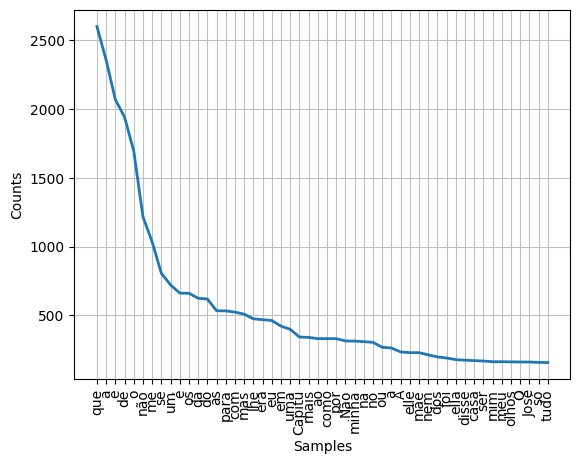

In [12]:
#Você pode contar a frequência de cada palavra utilizando a biblioteca nltk.FreqDist(lista de palavras)
#Você pode plotar o gráfico com o método plot() do objeto nltk.FreqDist() exemplo a seguir
%matplotlib inline

#Seu código de contagem aqui, armazenando na variável contagem
contagem = nltk.FreqDist(tokens)

contagem.plot(50)

2. Agora normalize o texto colocando todas as palavras da lista de tokens da etapa anterior em caixa baixa e verifique como se comporta a nova distribuição no gráfico.

In [22]:
#Você colocar cada palavra em caixa baixa percorrendo os tokens originais e utilizando a função lower() da própria classe String.
#Cada novo token que foi colocado em caixa baixa pode ser adicionado a uma lista auxiliar tokens_lw

#1. Você pode realizar a tokenização utilizando a biblioteca re.find(), re.split() ou a nltk.tokenize.RegexpTokenizer() passando sua expressão e chamando o método tokenize
# Tokenize e armazene o resultado em uma variável chamada tokens

tokens_lw = [token.lower() for token in tokens]
set_tokens_lw = list(set(tokens_lw))
print(f"{len(set_tokens_lw)} palavras foram encontradas.")
print(tokens_lw[:10])

8990 palavras foram encontradas.
['uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'engenho', 'novo']


<Axes: xlabel='Samples', ylabel='Counts'>

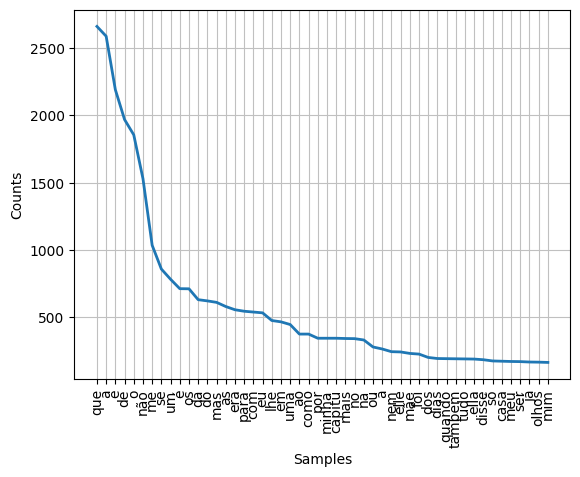

In [15]:
#Refaça a contagem e plote o novo gráfico utilizando a mesma biblioteca da etapa anterior
%matplotlib inline

#Seu código de contagem aqui, armazenando na variável contagem_lower
#contagem_lower.plot(50)

contagem_lower = nltk.FreqDist(tokens_lw)
contagem_lower.plot(50)

3. Remova as stopwords da lista de tokens da etapa anterior e refaça o processo para verificar se a lei de Zipf se mantém. Para isso, utilize stopwords da mesma língua do texto.

In [17]:
#Você pode remover as stopwords recuperando-as da lista da biblioteca stopwords.words('portuguese')
#A verificação pode ser feita, percorrendo sua lista de tokens atual e verificando se aquele token não é uma stopword
#Os tokens que não são stopwords devem ser adicionados a uma lista tokens_lw_sw

stop_words_portugues = stopwords.words("portuguese")
tokens_lw_sw = [x for x in tokens_lw if x not in stop_words_portugues]
print(tokens_lw_sw[0:8])

['noite', 'destas', 'vindo', 'cidade', 'engenho', 'novo', 'encontrei', 'trem']


<Axes: xlabel='Samples', ylabel='Counts'>

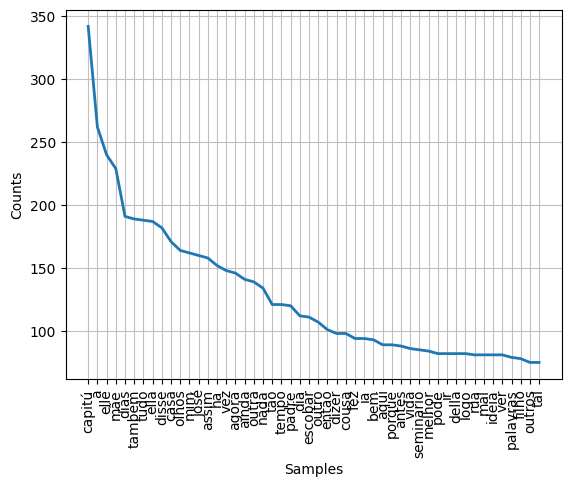

In [18]:
#Refaça a contagem com nltk.FreqDist e plote o gráfico
%matplotlib inline

#Seu código de contagem aqui
contagem_lw_ns = nltk.FreqDist(tokens_lw_sw)

#Seu código de contagem aqui, armazenando na variável contagem
contagem_lw_ns.plot(50)

4. Agora aplique a etapa de stemming na lista de tokens da etapa e refaça o processo para verificar se a lei de Zipf se mantém. Para isso utilize alguma biblioteca de stemming.

In [24]:
#Você pode aplicar a etapa de stemming utilizando a função stem(token) da classe PorterStemmer() em cada token da lista
#Cada token que passou pelo processo de stemming deve ser adicionado à lista tokens_lw_sw_st

stemmer = PorterStemmer()
tokens_lw_sw_st = [stemmer.stem(x) for x in tokens_lw_sw]
print(tokens_lw_sw_st[0:10])

['noit', 'desta', 'vindo', 'cidad', 'engenho', 'novo', 'encontrei', 'trem', 'central', 'rapaz']


<Axes: xlabel='Samples', ylabel='Counts'>

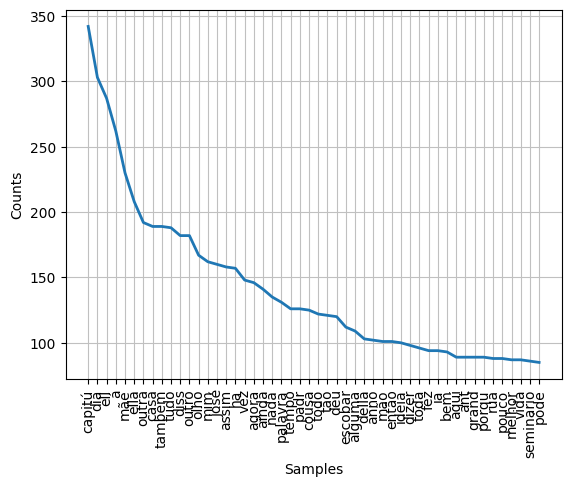

In [27]:
#Refaça a contagem e plote o novo gráfico utilizando a mesma biblioteca anterior
%matplotlib inline

contagem_lw_sw_st = nltk.FreqDist(tokens_lw_sw_st)
#Seu código de contagem aqui
contagem_lw_sw_st.plot(50)

5. Ao invés de considerar apenas a ocorrências das palavras unitárias (unigramas), agora utilize bigramas e trigramas. Plote o gráfico e verifique se a lei se mantém para essas novas estruturas. Faça isso com o texto original.

In [29]:
#Faça a contagem para o texto original que foi apenas tokenizado sem nenhum pré-processamento.
#Para contar os bigramas e trigramas você pode utilizar as funções bigrams e trigrams do nltk, o resultado deve ser transformado em lista

bigram_tokens = list(nltk.bigrams(tokens))
trigram_tokens = list(nltk.trigrams(tokens))

print(bigram_tokens[0:5])
print(trigram_tokens[0:5])

[('Uma', 'noite'), ('noite', 'destas'), ('destas', 'vindo'), ('vindo', 'da'), ('da', 'cidade')]
[('Uma', 'noite', 'destas'), ('noite', 'destas', 'vindo'), ('destas', 'vindo', 'da'), ('vindo', 'da', 'cidade'), ('da', 'cidade', 'para')]


<Axes: xlabel='Samples', ylabel='Counts'>

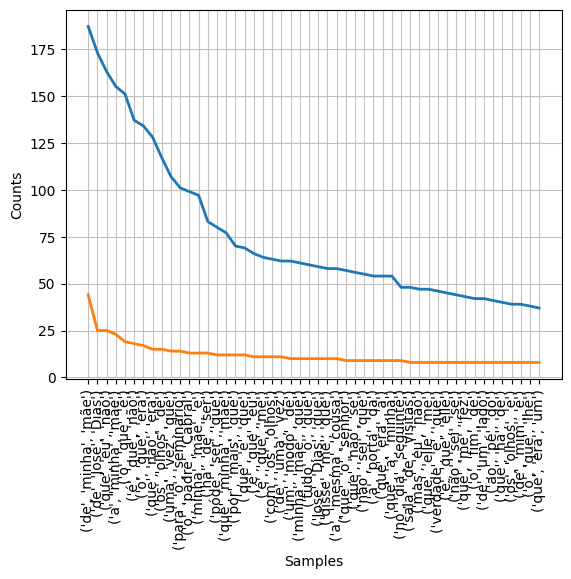

In [31]:
#Faça a contagem dos bigramas e trigramas e plote cada um em um gráfico, você pode aplicar a nltk.FreqDist(bigramas ou trigramas)
%matplotlib inline

contagem_bigram_tokens = nltk.FreqDist(bigram_tokens)
contagem_trigram_tokens = nltk.FreqDist(trigram_tokens)

#Seu código de contagem aqui
contagem_bigram_tokens.plot(50)
contagem_trigram_tokens.plot(50)

<Axes: xlabel='Samples', ylabel='Counts'>

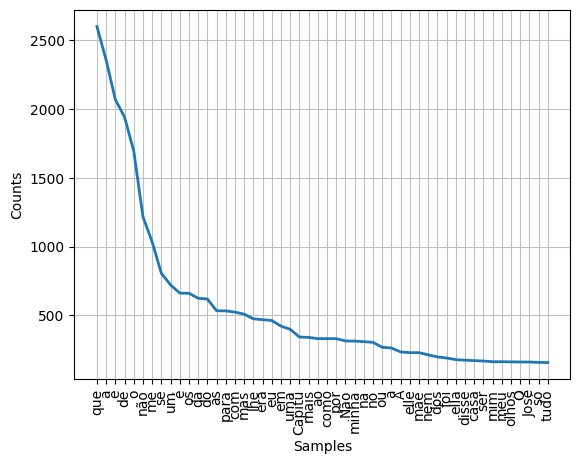

In [ ]:
%matplotlib inline

contagem_trigram_tokens = nltk.FreqDist(tokens)

#Seu código de contagem aqui
contagem_trigram_tokens.plot(50)

## Perguntas (Lei de Zipf)

**1. Considerando o texto sem nenhum tipo de pré-processamento (apenas tokenização), o livro segue a Lei de Zipf? Também considerando bigramas e trigramas? Justifique.**
- Resposta: `Por definição, a Lei de Zipf diz que poucas palavras ocorrem com muita frequência, enquanto muitas palavras ocorrem raramente. Ou seja, a frequência de uma palavra é inversamente proporcional a sua posição no ranking.`

- `Então sim, o livro segue uma distribuição de Zipf para palavras isoladas (unigramas) e para bigramas. Percebe-se que palavras conhecidas como stopwords (palavras que sozinhas tem pouco significado) ocorre bastante nesta corpora. Além de perceber que as bigramas seguem uma distribuição de Zipf, as trigramas também seguem, mas são mais esparsas.`

**2. Considerando as etapas do pré-processamento, a lei de Zipf se mantém entre elas? Justifique.**
- Resposta: `Sim, se mantém para quando deixamos todas as palavras em minúsculas. Mas depois de remover as stopwords, muitas palavras que ocorrem bastante foram removidas. Mas mesmo assim, aparecem algumas palavras com pouco significado como a letra "a", "elle", "vez", ... , isso ocorreu porque a lista de stopwords não contempla essas palavras, portanto seria necessário adicioná-las a lista manualmente para remover. Outro fator importante foi que o texto é composto de palavras do português antigo, portanto a lista de stopwords não tem esses dados Inclusive, alguma palavras como "a", "elle", ... sofreram perdas de frequência ao aplicar o stemming.`

**3. Em alguma das etapas do pré-processamento, as palavras mais frequentes são relacionadas com o enredo do livro?**
- Resposta: `Pelo trecho e pela distribuição de frequência, dá pra perceber que as palavras mais frequentes ainda estão muito ligadas ao conteúdo narrativo (enredo), o que indica que o pré-processamento não removeu totalmente termos semanticamente relevantes.`

## **Modelos de Linguagem N-Gramas**
Vamos gerar modelos de linguagem utilizando n-gramas e verificar se é possível predizer textos que se assemelham ao texto original. Nessa etapa, não precisaremos utilizar todas as tarefas do pré-processamento, pois pretendemos que nosso modelo seja o mais fiel possível aos dados originais. Siga os passos abaixo:

## **Modelos Bi-Gram**

1. Antes de tokenizarmos, é necessário fazermos alguns ajustes no texto original, para que nosso modelo possa capturar a distribuição real das sequências. Para isso, em cada sentença, devemos incluir o marcardor `<s>` no início e `</s>` no fim.

In [33]:
#Você pode adicionar os marcadores de início e fim do texto utilizando regex.
#Inicialmente vamos substituir a sequência ... pelo caractere vazio, pois há várias ocorrências de ...
#Dica: use a função re.sub()
texto_mk = '<s> ' + texto_original + ' </s>'
texto_mk = re.sub(r"(\.\.\.)", "", texto_mk)

print(texto_mk[:200])

<s> 
Uma noite destas, vindo da cidade para o
Engenho Novo, encontrei no trem da Central um
rapaz aqui do bairro, que eu conheço de vista e de
chapéo. Comprimentou-me, sentou-se ao pé de
mim, falo


In [34]:
#Sempre que aparece um ponto final, na maioria das vezes isso significa o fim de uma sentença e o início de uma nova sentença.
#podemos trocar todos os pontos que são de borda (seguidos ou não por espaço) por </s> <s> .
#Dica: use a função re.sub()
texto_mk = re.sub(r"(\.)", "</s> <s>", texto_mk)
print(texto_mk[:200])

<s> 
Uma noite destas, vindo da cidade para o
Engenho Novo, encontrei no trem da Central um
rapaz aqui do bairro, que eu conheço de vista e de
chapéo</s> <s> Comprimentou-me, sentou-se ao pé de
mi


2. Agora devemos tokenizar considerando somente palavras que contém letras mantendo os marcadores de início e fim para mantermos a distribuição original das palavras nas sentenças do nosso texto.

In [35]:
# A Tokenização pode ser feita com a biblioteca re. ou nltk.tokenize.RegexpTokenizer() chamando o método tokenize(lista de tokens).
# Essa parte está completa! Esse é um exemplo de função que você pode usar para fazer a tokenização:
tokenizer = nltk.tokenize.RegexpTokenizer('[^\s,\d]+')
tokens_mk = tokenizer.tokenize(texto_mk)

print(tokens_mk[0:40])

['<s>', 'Uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'Engenho', 'Novo', 'encontrei', 'no', 'trem', 'da', 'Central', 'um', 'rapaz', 'aqui', 'do', 'bairro', 'que', 'eu', 'conheço', 'de', 'vista', 'e', 'de', 'chapéo</s>', '<s>', 'Comprimentou-me', 'sentou-se', 'ao', 'pé', 'de', 'mim', 'falou', 'da', 'lua', 'e']


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13146/4214517361.py:3: SyntaxWarning: invalid escape sequence '\s'
  tokenizer = nltk.tokenize.RegexpTokenizer('[^\s,\d]+')


In [36]:
# Transforme cada token da etapa original para caixa baixa. Isso possibilita ao modelo uma maior generalização.
# Para isso, você pode percorrer sua lista de tokens e aplicar a função lower() em cada token, salvando o token na lista tokens_mk_lw

tokens_mk_lw = list([x.lower() for x in tokens_mk])

print(tokens_mk_lw[0:10])

['<s>', 'uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'engenho']


3. Vamos gerar os bigramas utilizando a lista de tokens da etapa anterior assim como sua contagem.

In [37]:
#Você pode utilizar a função bigrams na sua lista de tokens e salvar o resultado na variável bigrams_mk

bigrams_mk = list(nltk.bigrams(tokens_mk_lw))

print(bigrams_mk[:10])

[('<s>', 'uma'), ('uma', 'noite'), ('noite', 'destas'), ('destas', 'vindo'), ('vindo', 'da'), ('da', 'cidade'), ('cidade', 'para'), ('para', 'o'), ('o', 'engenho'), ('engenho', 'novo')]


4. Vamos remover o bigrama (`<\s>`, `<s>`), pois eles não fazem parte da distribuição real nas sentenças.

In [38]:
#Essa remoção evita que os bigramas (<\s>, <s>) e ('<s>', '</s>') influenciem nas contagens
#Essa parte está completa!
bigrams_mk_filtrado = [bg for bg in bigrams_mk if (bg != ('</s>', '<s>') and bg != ('<s>', '</s>'))]
print(bigrams_mk_filtrado[:10])

[('<s>', 'uma'), ('uma', 'noite'), ('noite', 'destas'), ('destas', 'vindo'), ('vindo', 'da'), ('da', 'cidade'), ('cidade', 'para'), ('para', 'o'), ('o', 'engenho'), ('engenho', 'novo')]


### **Probabilidade Condicional - Bi-Gram**
Nessa etapa, vamos calcular a probabilidade condicional de cada bigrama. Lembrando que isso pode ser feito pelo estimador de máxima verossimilhança:


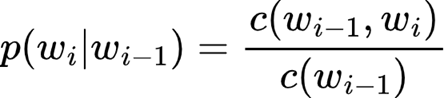

1. Pela fórmula , devemos contar a frequência dos bigramas (Numerador) assim como a frequência de de cada palavra anterior (Denominador).

In [39]:
#Para contar unigramas você pode utilizar a nltk.FreqDist() passando a lista de tokens

freq_unigram = nltk.FreqDist(tokens_mk_lw)
freq_bigram = nltk.FreqDist(bigrams_mk_filtrado)

print(freq_unigram.most_common(5))
print(freq_bigram.most_common(5))

[('<s>', 3558), ('que', 2627), ('a', 2467), ('e', 2167), ('de', 1968)]
[(('que', 'não'), 180), (('que', 'me'), 176), (('o', 'que'), 173), (('<s>', 'a'), 169), (('<s>', 'não'), 168)]


2. Calcule cada probabilidade condicional. Para cada bigrama, divida sua contagem pela contagem da primeira palavra do bigrama.

In [40]:
#A estrutura abaixo já percorre cada bigrama sendo possível acessar suas palavras w1 e w2.
#Você pode usar essas palavras para acessar a frequência do bigrama, usando-as como chave para recuperar sua contagem
#O mesmo pode ser feito com os unigramas

cond_prob = {}
for (w1, w2) in bigrams_mk_filtrado:

    #calcule a probabilidade condicional aqui e armazene em prob
    prob = freq_bigram[(w1, w2)] / freq_unigram[w1]
    cond_prob[(w1, w2)] = prob

for (w1, w2), p in list(cond_prob.items())[:5]:
    print(f"P({w2} | {w1}) = {p:.4f}")

P(uma | <s>) = 0.0073
P(noite | uma) = 0.0093
P(destas | noite) = 0.0312
P(vindo | destas) = 0.2500
P(da | vindo) = 0.1667


In [41]:
# Para verificar uma probabilidade, utilize as duas palavras como uma chave única no dicionário
print(bigrams_mk[:5])
cond_prob[('vindo', 'da')]

[('<s>', 'uma'), ('uma', 'noite'), ('noite', 'destas'), ('destas', 'vindo'), ('vindo', 'da')]


0.16666666666666666

3. Utilize a função abaixo para gerar algumas sentenças com seu modelo bigrama. A função já está pronta, nada deve ser feito, apenas invocá-la passando seu dicionário (variável cond_prob) de probabilidades condicionais.

In [42]:
import random

def gerar_sentenca_shannon_bigram(cond_prob):
    sentenca = []
    w1 = '<s>'

    while True:
        # Obter todas as palavras w2 possíveis dado w1
        candidatos = [(w2, prob) for (prev, w2), prob in cond_prob.items() if prev == w1]

        if not candidatos:
            break  # não há continuidade possível

        # Separar palavras e probabilidades
        palavras, probs = zip(*candidatos)

        # Amostrar uma palavra com base nas probabilidades
        w2 = random.choices(palavras, weights=probs, k=1)[0]

        if w2 == '</s>':
            break

        sentenca.append(w2)
        w1 = w2

    return ' '.join(sentenca)

In [43]:
#Gere e exiba a primeira sentença
sent = gerar_sentenca_shannon_bigram(cond_prob)
print(sent)

o imperador ácerca da miseravel tocha</s> <s> as dansas fantasticas dos erros da outra</s> <s> estava em commissão</s> <s> nunca me deram o fim de $


In [44]:
#Gere e exiba a segunda sentença
sent = gerar_sentenca_shannon_bigram(cond_prob)
print(sent)

mandei fazer o choro elle queria noticias de theologia vinham ou já pelo tempo levou; converto-me á minha historia</s> <s> não obstante o meu nome escripto um cavallo por simples e quatro e eu faço em casa e pallida bocca fóra</s> <s> foi para se corta uma resolução que os dous annos</s> <s> —daqui a inquirir do calor que no pescoço enterral-as bem não comporia bolas de sirius</s> <s> xxiii prazo dado</s> <s> em que me lerem melhor podia ir para as duvidas cxvifilho do fim de collegio donde elle é grave e irá comnosco</s> <s> tudo é sempre que eu conhecia as ondas</s> <s> não posso continuei a haveria que demolissem a verdade mas eu amava particularmente os tres mezes e comprimarias córos e ergueu-se</s> <s> você case você? que uma cousa que elle e do trem da promessa</s> <s> peguei-lhe levemente grossas ou o tempo de café</s> <s> suspendamos a beber cogitei se é pessoa que me olhou para ella</s> <s> quanto antes</s> <s> tio cosme: «anda lá em que comprehendo o visinho padua começou a 

In [45]:
#Gere e exiba a terceira sentença
sent = gerar_sentenca_shannon_bigram(cond_prob)
print(sent)

os rapazes da escriptura: «muitos são precisos os olhos a dôr do ceu</s> <s> creio que me foi como o pae faz que não corri ao gabinete do quintal</s> <s> o que a vida peor; é o cemiterio de falar e teimosos perguntou-me: —diga-me uma das outras</s> <s> —mas passa; mas não sei que deus recebe em deixal-a sem que eu sei se vae por josé dias está muito intelligentes mas não confundam purgatorio é impossivel que não acharás mais que é que a perna e vae para a namorar-lhe a algum texto dando-lhe o mar que vi a alegria que me lembra agora; lembra-me bem explicado</s> <s> esta exclamação: «ouço a palavra saiu assim depressa como que para as nossas sympathias a primeira hora bravia</s> <s> só atrevidas e olhos no ar; ouvi a nossa separação é indelevel</s> <s> toda hora da casa; enfiei hontem</s> <s> cii de que os tem boa alma alliviada de escobar fez-se còr de alguns dias é ter tirado a russia manduca vivia com o mesmo do homem que jura</s> <s> tinha febre</s> <s> —seja feliz! disse-me</s> <s>

4. Calcule a Perplexidade de uma das sentenças geradas.

In [48]:
#Utilize uma das sentenças geradas e aplique o método split() para quebrá-la por espaços e salve na variável sentence_tokens
#Gere os bigramas para a lista de tokens obtidas com o split()
#Percorra cada bigrama e recupere a probabilidade desse bigrama que está no dicionário cond_prob
#Multiplique todas as probabilidades e armazene o resultado na variável sentence_probabilities

import numpy as np
import nltk

sentence_tokens = sent.split(" ")
bigrams_sentence_tokens = list(nltk.bigrams(sentence_tokens))

log_prob_sum = 0

for (w1, w2) in bigrams_sentence_tokens:
    prob = cond_prob.get((w1, w2), 1e-6)
    log_prob_sum += np.log(prob)

# Perplexidade usando log diretamente
sentence_perplexity = np.exp(-log_prob_sum / len(sentence_tokens))

print(f"Log probabilidade: {log_prob_sum:.4f}")
print(f"Perplexidade da sentença: {sentence_perplexity:.4f}")

Log probabilidade: -5321.2137
Perplexidade da sentença: 26.7552


## **Perguntas**

**1. As sentenças geradas com o algoritmo de shannon, fizeram sentido ou apresentam partes com sentido? Justifique**

`As sentenças geradas não fazem sentido completo, mas apresentam trechos com sentido local. Por exemplo, para a sentença "era natural admirar as mãos tremiam-me", tem um certo sentido, mas para outras sentenças como "a investidura ecclesiastica jurámos pela alma de tudo passado bem irritado com o espectaculo era mas um projecto para jantar" não formam uma ideia clara. Isso acontece porque o algoritmo aprende probabilidades de sequência de palavras, sendo assim, ele não contempla contexto global, narrativa e semântica. Ou seja, possa ser que há trechos com sentido localmente mas não globalmente, pois ele usa probabilidades. Além disso, ao usar bigramas unigramas, o algortimo tem maior probabilidade de encontrar uma ocorrencia nos dados, quanto maior for o n-grama, maior é a probabilidade de não encontrar a ocorrência nos dados para prever o próximo token.`

# Para CASA
Tente adaptar o modelo bigrama para trigrama e compare os resultados. Essa etapa não deve ser enviada como resultado do lab. Dica: agora o início e final de cada sentença deve agora considerar dois `<s>` e `</s>`

In [64]:
import nltk
import random
import numpy as np

texto_mk = re.sub(r"(\.\.\.)", "", texto_original)
texto_mk = re.sub(r"(\.)", " </s> <s> <s> ", texto_mk)
texto_mk = "<s> <s> " + texto_mk + " </s> </s>"
tokenizer = nltk.tokenize.RegexpTokenizer(r'[^\s,\d]+')
tokens_mk = tokenizer.tokenize(texto_mk)

print(tokens_mk[0:40])

def adicionar_tokens_inicio_fim(tokens):
    tokens_novos = []
    tokens_novos.append('<s>')
    tokens_novos.append('<s>')

    for t in tokens:
        tokens_novos.append(t)
        if t == '</s>':
            tokens_novos.append('<s>')
            tokens_novos.append('<s>')

    return tokens_novos


tokens = tokens_mk
bigrams = list(nltk.bigrams(tokens))
trigrams = list(nltk.trigrams(tokens))
print([tg for tg in trigrams if tg[0] == '<s>' and tg[1] == '<s>'][:10])

trigrams_filtrados = [
    tg for tg in trigrams
    if not (tg[0] == '</s>' and tg[1] == '</s>')
]


freq_bigram = nltk.FreqDist(bigrams)
freq_trigram = nltk.FreqDist(trigrams_filtrados)


cond_prob = {}
for (w1, w2, w3) in trigrams_filtrados:
    if freq_bigram[(w1, w2)] > 0:
        prob = freq_trigram[(w1, w2, w3)] / freq_bigram[(w1, w2)]
        cond_prob[(w1, w2, w3)] = prob


for (w1, w2, w3), p in list(cond_prob.items())[:10]:
    print(f"P({w3} | {w1}, {w2}) = {p:.4f}")



def gerar_sentenca_trigrama(cond_prob, max_len=30):
    sentenca = []
    w1, w2 = '<s>', '<s>'

    for _ in range(max_len):
        candidatos = [
            (w3, prob)
            for (prev1, prev2, w3), prob in cond_prob.items()
            if prev1 == w1 and prev2 == w2
        ]

        if not candidatos:
            break

        palavras, probs = zip(*candidatos)
        w3 = random.choices(palavras, weights=probs, k=1)[0]

        if w3 == '</s>':
            break

        sentenca.append(w3)
        w1, w2 = w2, w3

    return ' '.join(sentenca)


sent = gerar_sentenca_trigrama(cond_prob)
print("\nSentença gerada:")
print(sent)

['<s>', '<s>', 'Uma', 'noite', 'destas', 'vindo', 'da', 'cidade', 'para', 'o', 'Engenho', 'Novo', 'encontrei', 'no', 'trem', 'da', 'Central', 'um', 'rapaz', 'aqui', 'do', 'bairro', 'que', 'eu', 'conheço', 'de', 'vista', 'e', 'de', 'chapéo', '</s>', '<s>', '<s>', 'Comprimentou-me', 'sentou-se', 'ao', 'pé', 'de', 'mim', 'falou']
[('<s>', '<s>', 'Uma'), ('<s>', '<s>', 'Comprimentou-me'), ('<s>', '<s>', 'A'), ('<s>', '<s>', 'Succedeu'), ('<s>', '<s>', '—Continue'), ('<s>', '<s>', '—Já'), ('<s>', '<s>', '—São'), ('<s>', '<s>', 'Vi-lhe'), ('<s>', '<s>', 'No'), ('<s>', '<s>', 'Os')]
P(Uma | <s>, <s>) = 0.0072
P(noite | <s>, Uma) = 0.1154
P(destas | Uma, noite) = 0.3333
P(vindo | noite, destas) = 1.0000
P(da | destas, vindo) = 1.0000
P(cidade | vindo, da) = 1.0000
P(para | da, cidade) = 0.1429
P(o | cidade, para) = 1.0000
P(Engenho | para, o) = 0.0303
P(Novo | o, Engenho) = 1.0000

Sentença gerada:
Em vez de trepadas no ar os olhos de ressaca XXXIIIO penteado XXXIVSou homem! XXXVO protonotario

In [68]:
def calcular_perplexidade(sent, cond_prob):
    tokens = sent.split()
    tokens = ['<s>', '<s>'] + tokens + ['</s>']

    trigrams_sent = list(nltk.trigrams(tokens))

    log_prob = 0

    for (w1, w2, w3) in trigrams_sent:
        prob = cond_prob.get((w1, w2, w3), 1e-6)
        log_prob += np.log(prob)

    perplexidade = np.exp(-log_prob / len(tokens))
    return perplexidade


pp = calcular_perplexidade(sent, cond_prob)
print(f"\nPerplexidade: {pp:.4f}")


Perplexidade: 2.4182
